# Comparison with PSI reduction software

This notebook is for validating the results from the `essreflectometry` packages by comparing them
to the ones obtained by the PSI software at the Amor beamline.

In [1]:
import warnings
import orsopy
import matplotlib.pyplot as plt

import scipp as sc
import plopp as pp
from ess import amor
from ess.amor import data  # noqa: F401
from ess.reflectometry.types import *
from ess.amor.types import ChopperPhase

# The files used in this tutorial have some issues that makes scippnexus
# raise warnings when loading them. To avoid noise in the notebook the warnings are silenced.
warnings.filterwarnings('ignore', 'Failed to convert .* into a transformation')
warnings.filterwarnings('ignore', 'Invalid transformation, missing attribute')

## Recreate reference files using Jochens Amor data reduction software

#### step 1
```
%%bash
git clone https://github.com/jochenstahn/amor.git
wget -P raw https://public.esss.dk/groups/scipp/ess/amor/1/amor2023n000{608..614}.hdf
```

#### step 2
```
%%bash
args='-Y 2023 -d raw -n 614 -m 0.05 -co -7.5 -of ort'

rm raw/614.norm
python amor/neos.py $args -f 614

for i in `seq 608 613`
do
    python amor/neos.py $args -f $i -o $i
done
```

## Run essreflectometry on the same files

In [2]:
workflow = amor.AmorWorkflow()

workflow[SampleSize[SampleRun]] = sc.scalar(10.0, unit='mm')
workflow[SampleSize[ReferenceRun]] = sc.scalar(10.0, unit='mm')
workflow[ChopperPhase[SampleRun]] = sc.scalar(-7.5, unit='deg')

workflow[WavelengthBins] = sc.geomspace('wavelength', 2.8, 12.5, 2001, unit='angstrom')
workflow[QBins] = sc.geomspace(
    dim='Q', start=0.00505, stop=2.93164766e-01, num=391, unit='1/angstrom'
)
workflow[YIndexLimits] = sc.scalar(11), sc.scalar(41)
workflow[ZIndexLimits] = sc.scalar(80), sc.scalar(370)
workflow[BeamDivergenceLimits] = sc.scalar(-0.75, unit='deg'), sc.scalar(0.75, unit='deg')

# Chopper phase value in the file is wrong, so we set it manually
workflow[ChopperPhase[ReferenceRun]] = sc.scalar(-7.5, unit='deg')
# The sample rotation value in the file is slightly off, so we set it manually
workflow[SampleRotationOffset[ReferenceRun]] = sc.scalar(0.05, unit='deg')
workflow[Filename[ReferenceRun]] = amor.data.amor_run(614)

reference_result = workflow.compute(ReducedReference)
# Set the result back onto the pipeline to cache it
workflow[ReducedReference] = reference_result

/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/height missing attribute 'vector'
  return maybe_transformation(self, value=dg)
/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/rotation missing attribute 'vector'
  return maybe_transformation(self, value=dg)


In [3]:
mu = {
    '608': 0.8,
    '609': 2.2,
    '610': 3.6,
    '611': 5.0,
    '612': 0.6,
    '613': 0.6,
}

results = sc.DataGroup({'ess': sc.DataGroup(), 'psi': sc.DataGroup()})

# ESS results
for key in mu:
    print(key, '... ', end='')
    workflow[SampleRotationOffset[SampleRun]] = sc.scalar(0.05, unit='deg')
    workflow[Filename[SampleRun]] = amor.data.amor_run(key)
    da = workflow.compute(ReflectivityOverQ).hist()
    da.coords['Q'] = sc.midpoints(da.coords['Q'], dim='Q')
    results['ess'][key] = da
    print('Done!')

608 ... 

/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/height missing attribute 'vector'
  return maybe_transformation(self, value=dg)
/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/rotation missing attribute 'vector'
  return maybe_transformation(self, value=dg)


Done!
609 ... 

/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/height missing attribute 'vector'
  return maybe_transformation(self, value=dg)
/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/rotation missing attribute 'vector'
  return maybe_transformation(self, value=dg)


Done!
610 ... 

...

Done!
612 ... 

/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/height missing attribute 'vector'
  return maybe_transformation(self, value=dg)
/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/rotation missing attribute 'vector'
  return maybe_transformation(self, value=dg)


Done!
613 ... 

/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/height missing attribute 'vector'
  return maybe_transformation(self, value=dg)
/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/scippnexus/base.py:402: UserWarning: Invalid transformation, /entry1/Amor/detector/transformation/rotation missing attribute 'vector'
  return maybe_transformation(self, value=dg)


Done!


In [4]:
# PSI results
for key in mu:
    d = orsopy.fileio.load_orso(amor.data.amor_psi_software_result(key))[0].data
    y = sc.array(dims=['Q'], values=d[:, 1], variances=d[:, 2] ** 2)
    results['psi'][key] = sc.DataArray(
        data=y, coords={'Q': sc.array(dims=['Q'], values=d[:, 0], unit='1/angstrom')}
    )

## Plot reflectivity curve comparison

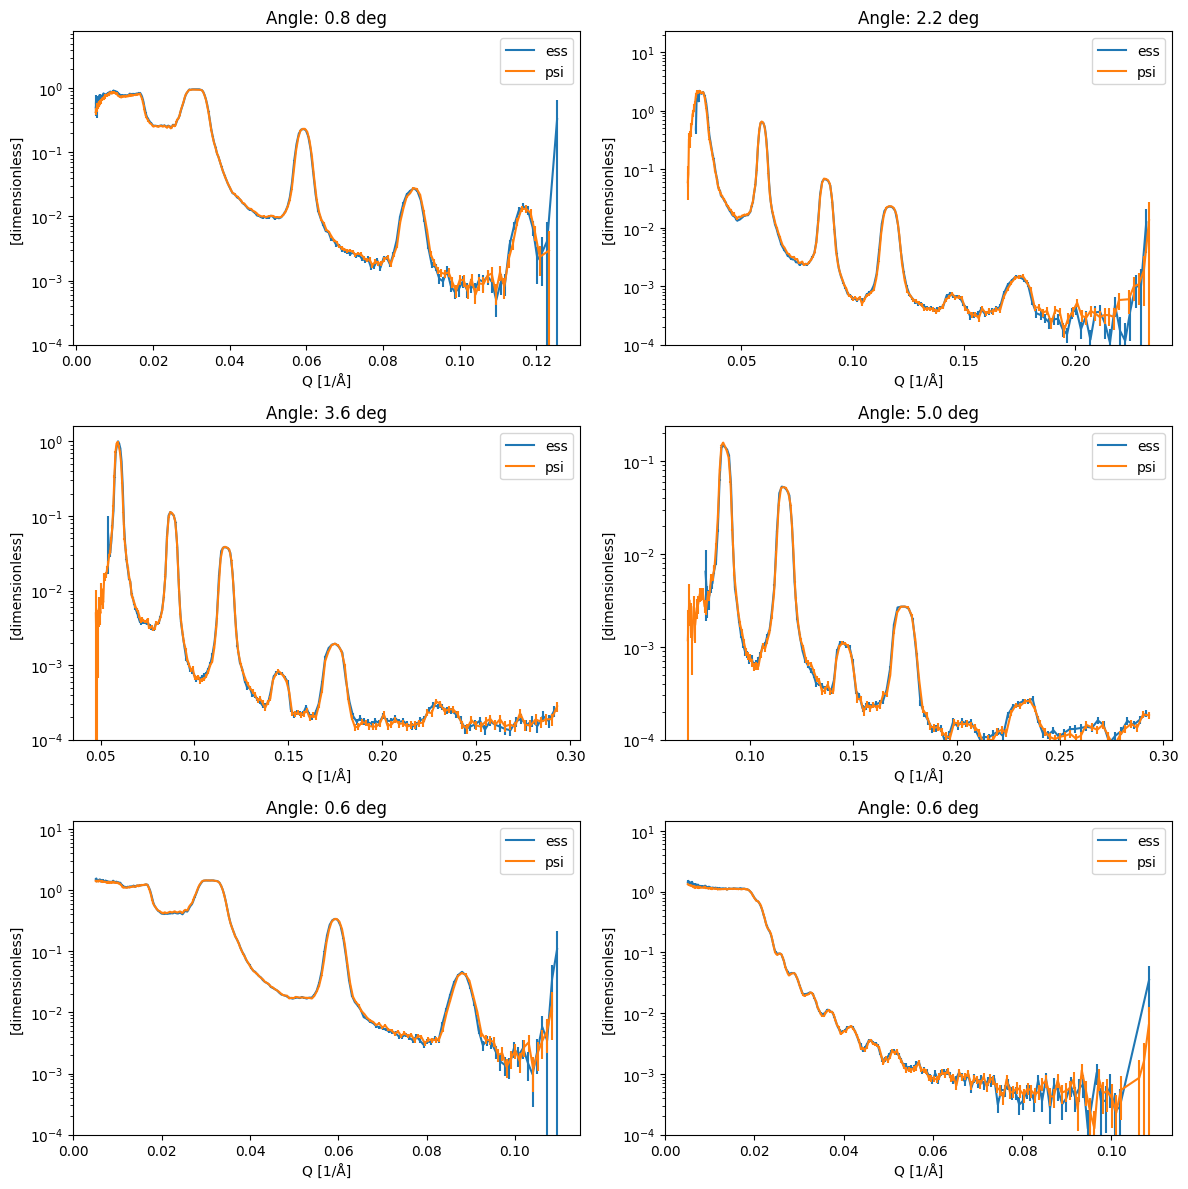

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

for ax, (key, angle) in zip(axs.ravel(), mu.items(), strict=True):
    pp.plot(
        {
            facility: results[facility][key][results[facility][key].data > 0.0]
            for facility in results
        },
        ax=ax,
        norm='log',
        ls='solid',
        marker=None,
        vmin=1.0e-4,
        title=f'Angle: {angle} deg',
    )

fig.tight_layout()

## Overlay curves from same sample at different angle, should be on top of each other

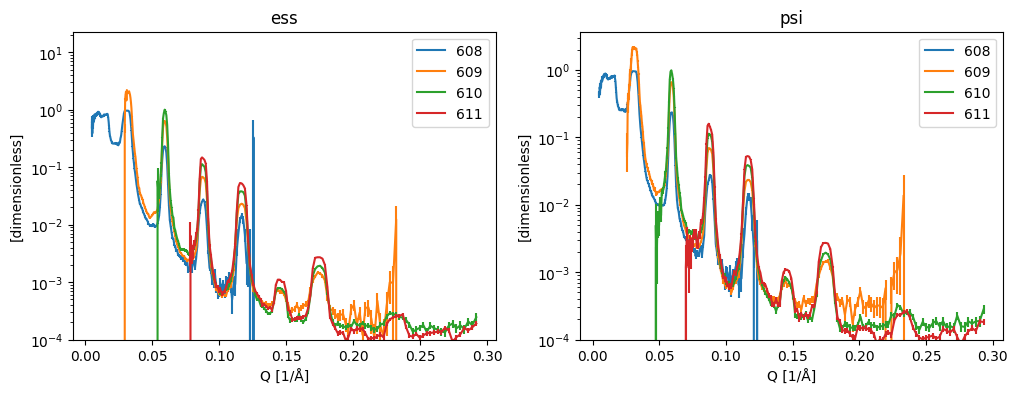

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for ax, (facility, res) in zip(axs.ravel(), results.items(), strict=True):
    pp.plot(
        dict(list(res.items())[:4]),  # First 4 curves
        ax=ax,
        norm='log',
        ls='solid',
        marker=None,
        vmin=1.0e-4,
        title=facility,
    )